In [2]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import QuantileTransformer

In [3]:
pairs = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "USDJPY": "USDJPY=X",
    "DXY": "DX-Y.NYB",
    "GOLD": "GC=F",
    "NAS100": "NQ=F"
}

start = "2026-04-20"
end = "2026-04-24"



In [ ]:
raw_data = {}

for name, ticker in pairs.items():
  df = yf.download(ticker, start=start, end=end, interval="1h")
  raw_data[name] = df
  print(f"{name}: {len(df)} rows pulled")

for name in raw_data:
    raw_data[name].columns = raw_data[name].columns.get_level_values(0)


In [ ]:
raw_data["NAS100"].head(5)

In [ ]:
def calculate_true_range(df):
  high = df["High"]
  low = df["Low"]
  prev_close = df["Close"].shift(1)

  tr = pd.concat([
      high - low,
      (high - prev_close).abs(),
      (low - prev_close).abs()
  ], axis=1). max(axis=1)

  df = df.copy()
  df["TR"] = tr
  df["Hour"] = df.index.hour
  df["DayOfWeek"] = df.index.day_name()

  return df

for name in raw_data:
  raw_data[name] = calculate_true_range(raw_data[name])

raw_data["NAS100"].head(10)

In [7]:
print(raw_data["GOLD"]["TR"].iloc[0])

75.0


In [ ]:
df = raw_data["EURUSD"]
print(df.columns)
print(df.index[0])
print(df.iloc[0])
print(df.iloc[1])

In [9]:
for name in raw_data:
  raw_data[name] = raw_data[name][raw_data[name]["DayOfWeek"] != "Sunday"]

In [10]:
for name in raw_data:
  raw_data[name].loc[raw_data[name].index[0], "TR"] = float("nan")
  raw_data[name] = raw_data[name].dropna(subset=["TR"])

In [ ]:
print("First row TR:", raw_data["EURUSD"]["TR"].iloc[0])

df = raw_data["EURUSD"]
invalid = df[df["TR"] < (df["High"] - df["Low"]) - 1e-10]
print(f"Invalid rows: {len(invalid)}")

In [ ]:
raw_data["DXY"].head(5)

In [ ]:
for name in raw_data:
 raw_data[name] = raw_data[name].drop(columns=["Volume"], errors="ignore")

raw_data["DXY"].head(10)

In [ ]:
raw_data["GBPUSD"].head(10)

In [ ]:
for name in raw_data:
  df = raw_data[name]
  invalid = df[df["TR"]<(df["High"] - df["Low"])-1e-10]
  print(f"{name}: Invalid rows: {len(invalid)}")

In [ ]:
hourly_volatility = {}

for name in raw_data:
  df = raw_data[name]
  hourly_avg = df.groupby("Hour")["TR"].mean()
  hourly_volatility[name] = hourly_avg


hourly_volatility["EURUSD"]

In [ ]:
plt.figure(figsize=(14, 5))
for name in hourly_volatility:
    plt.plot(hourly_volatility[name].index, hourly_volatility[name].values,
             label=name)

plt.title("Average Hourly Volatility by Asset - Last Week")
plt.xlabel("Hour (UTC)")
plt.ylabel("Average True Range")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, name in enumerate(hourly_volatility):
    axes[i].plot(hourly_volatility[name].index, hourly_volatility[name].values,
                 color="blue")
    axes[i].set_title(name)
    axes[i].set_xlabel("Hour (UTC)")
    axes[i].set_ylabel("Avg TR")
    axes[i].grid(True)

plt.suptitle("Hourly Volatility by Asset - Last Week", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
def label_session(df):
    conditions = [
        (df["Hour"] >= 0) & (df["Hour"] < 8),
        (df["Hour"] >= 8) & (df["Hour"] < 13),
        (df["Hour"] >= 13) & (df["Hour"] < 17),
        (df["Hour"] == 17),
        (df["Hour"] >= 18) & (df["Hour"] < 21),
        (df["Hour"] >= 21) & (df["Hour"] <= 23)
    ]

    labels = [
        "Asian",
        "London",
        "London-NY Overlap",
        "London Close",
        "New York",
        "Off Hours"
    ]

    df = df.copy()
    df["Session"] = np.select(conditions, labels, default="Unknown")
    return df

for name in raw_data:
    raw_data[name] = label_session(raw_data[name])

Next process is anomaly detection.

Step 1 — calculate a volatility threshold per asset. Any candle where TR exceeds the mean by a certain amount flags as an anomaly.

Step 2 — extract the exact timestamps of those anomalous candles.

Step 3 — cross reference those timestamps with an economic calendar or news feed to identify what caused the spike.

In [22]:
#anomaly detection

def detect_anomalies(df, contamination=0.005):
  df = df.copy()
  tr_value = df["TR"].values.reshape(-1, 1)

  # z-score
  z_scores = np.abs(stats.zscore(df["TR"]))
  df['zscore_anomaly'] = (z_scores > 3).astype(int)

  #IQR method
  Q1 = df['TR'].quantile(0.25)
  Q3 = df['TR'].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  df['iqr_anomaly'] = ((df['TR'] < lower) | (df['TR'] > upper)).astype(int)

  #isolation method
  scaler = QuantileTransformer()
  tr_scaled = scaler.fit_transform(tr_value)
  iso = IsolationForest(contamination=contamination, random_state=42)
  df['iso_anomaly'] = (iso.fit_predict(tr_scaled) == -1).astype(int)

  #ensemble -2 out of 3 must agree
  df['anomaly_votes'] = df["zscore_anomaly"] + df["iqr_anomaly"] + df["iso_anomaly"]
  df["is_anomaly"] = (df["anomaly_votes"] >= 2).astype(int)

  return df

for name in raw_data:
  raw_data[name] = detect_anomalies(raw_data[name])


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (92). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (92). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (92). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (91). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (86). n_qua

In [24]:
#output
anomalies = raw_data["NAS100"][raw_data["NAS100"]["is_anomaly"] == 1]
print(f"NAS100 anomalies detected: {len(anomalies)}")
print(anomalies[["Hour", "Session", "DayOfWeek", "TR", "anomaly_votes"]])

NAS100 anomalies detected: 1
Price                      Hour   Session DayOfWeek      TR  anomaly_votes
Datetime                                                                  
2026-04-23 17:00:00+00:00    17  New-York  Thursday  417.25              2


In [28]:
for name in raw_data:
    anomalies = raw_data[name][raw_data[name]["is_anomaly"] == 1]
    print(f"\n{name}: {len(anomalies)} anomalies")
    if len(anomalies) > 0:
        print(anomalies[["Hour", "Session", "DayOfWeek", "TR", "anomaly_votes"]])


EURUSD: 2 anomalies
Price                      Hour       Session DayOfWeek        TR  \
Datetime                                                            
2026-04-21 17:00:00+00:00    17  London Close   Tuesday  0.003724   
2026-04-23 17:00:00+00:00    17  London Close  Thursday  0.003280   

Price                      anomaly_votes  
Datetime                                  
2026-04-21 17:00:00+00:00              2  
2026-04-23 17:00:00+00:00              2  

GBPUSD: 2 anomalies
Price                      Hour       Session DayOfWeek        TR  \
Datetime                                                            
2026-04-21 17:00:00+00:00    17  London Close   Tuesday  0.004345   
2026-04-23 17:00:00+00:00    17  London Close  Thursday  0.004371   

Price                      anomaly_votes  
Datetime                                  
2026-04-21 17:00:00+00:00              2  
2026-04-23 17:00:00+00:00              2  

USDJPY: 1 anomalies
Price                      Hour       S

In [29]:
macro_events = {}

for name in raw_data:
    anomalies = raw_data[name][raw_data[name]["is_anomaly"] == 1]
    for timestamp in anomalies.index:
        if timestamp not in macro_events:
            macro_events[timestamp] = []
        macro_events[timestamp].append(name)

print("Timestamps where multiple assets spiked simultaneously:")
for timestamp, assets in sorted(macro_events.items()):
    if len(assets) >= 2:
        print(f"\n{timestamp}")
        print(f"Assets affected: {assets}")
        print(f"Asset count: {len(assets)}")

Timestamps where multiple assets spiked simultaneously:

2026-04-21 17:00:00+00:00
Assets affected: ['EURUSD', 'GBPUSD', 'USDJPY', 'DXY']
Asset count: 4

2026-04-23 17:00:00+00:00
Assets affected: ['EURUSD', 'GBPUSD', 'DXY', 'GOLD', 'NAS100']
Asset count: 5


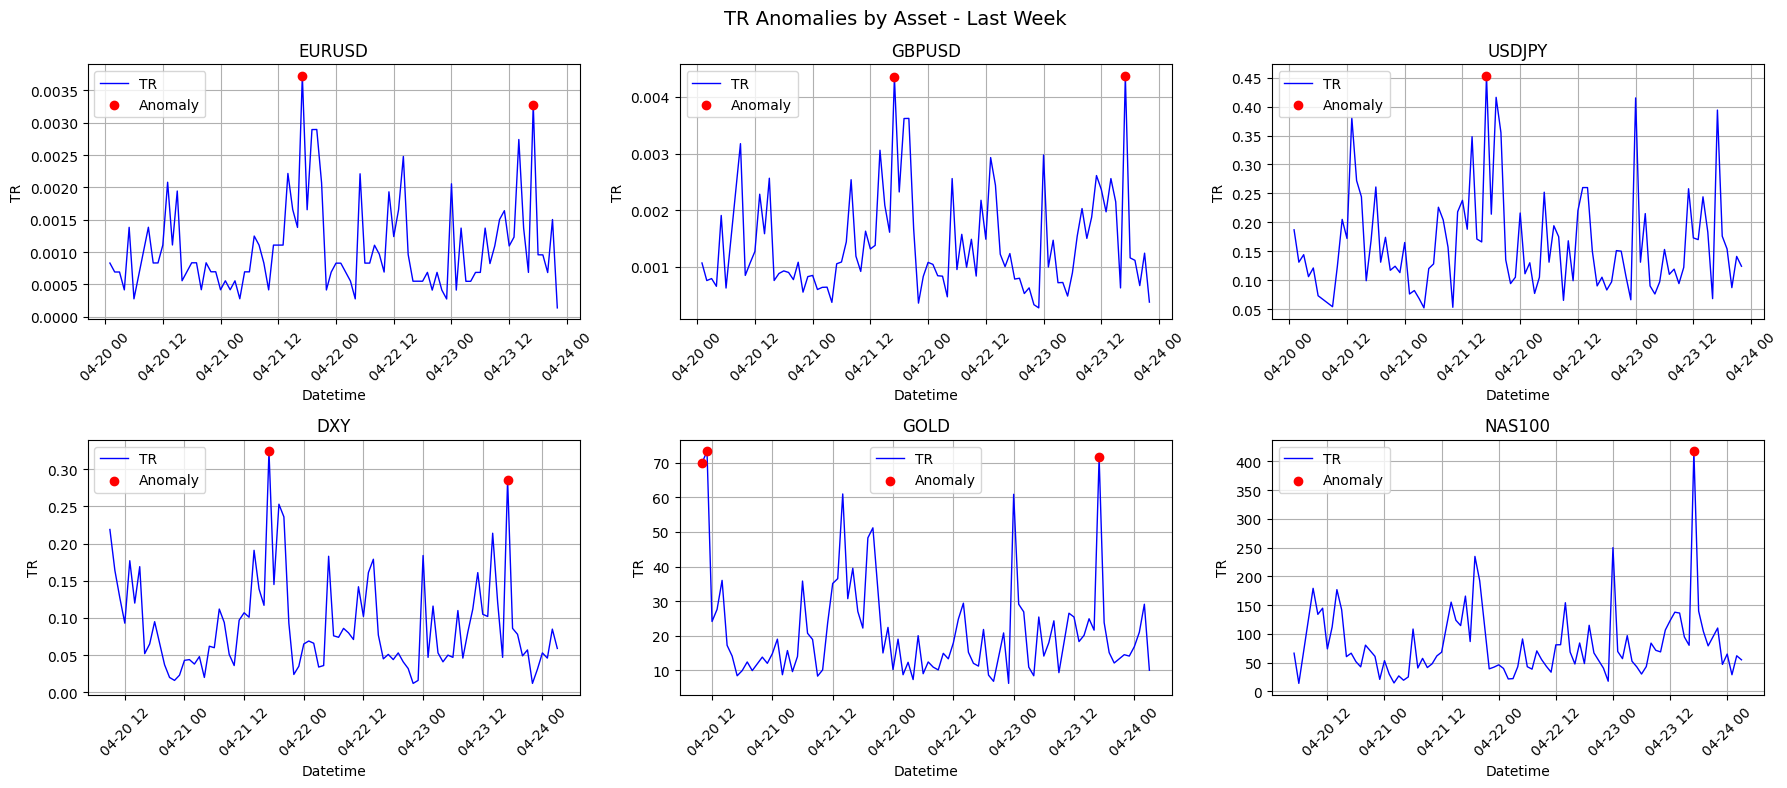

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, name in enumerate(raw_data):
    df = raw_data[name]
    ax = axes[i]

    ax.plot(df.index, df["TR"], color="blue", linewidth=1, label="TR")

    anomalies = df[df["is_anomaly"] == 1]
    ax.scatter(anomalies.index, anomalies["TR"], color="red", zorder=5,
               label="Anomaly")

    ax.set_title(name)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("TR")
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("TR Anomalies by Asset - Last Week", fontsize=14)
plt.tight_layout()
plt.show()